In [69]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, KFold
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, VotingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.metrics import classification_report, confusion_matrix
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 尝试导入高级模型库
try:
    import xgboost as xgb
    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False
    print("⚠️ XGBoost 未安装，某些功能将不可用")

try:
    import lightgbm as lgb
    LGB_AVAILABLE = True
except ImportError:
    LGB_AVAILABLE = False
    print("⚠️ LightGBM 未安装，某些功能将不可用")

# 读取数据
# 注：如果只有第一行是字符串类型（即表头或单位行），可以通过跳过第一行后处理，或者显式指定dtype
df = pd.read_csv("test.csv")
print(f"原始数据形状: {df.shape}")
print(f"\n数据列名:")
print(df.columns.tolist())

# 若发现数值列被错误解析为object，通常是因为第一行内容导致
# 显式转换索赔金额和保价金额为数值型（忽略无法解析的非数值）
for col in ['索赔金额', '保价金额', '实际赔付金额']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# 检查并处理负值：索赔金额和保价金额
print(f"\n=== 负值检查和处理 ===")

# 检查索赔金额负值
claim_negative_count = (df['索赔金额'] < 0).sum()
print(f"索赔金额负值数量: {claim_negative_count}")
if claim_negative_count > 0:
    negative_claims = df[df['索赔金额'] < 0]['索赔金额']
    print(f"索赔金额负值范围: {negative_claims.min():.2f} ~ {negative_claims.max():.2f}")
    df['索赔金额'] = df['索赔金额'].clip(lower=0)  # 将负值替换为0
    print(f"✓ 已将 {claim_negative_count} 个负值替换为0")
else:
    print("✓ 索赔金额无负值")

# 检查保价金额负值
insurance_negative_count = (df['保价金额'] < 0).sum()
print(f"保价金额负值数量: {insurance_negative_count}")
if insurance_negative_count > 0:
    negative_insurance = df[df['保价金额'] < 0]['保价金额']
    print(f"保价金额负值范围: {negative_insurance.min():.2f} ~ {negative_insurance.max():.2f}")
    df['保价金额'] = df['保价金额'].clip(lower=0)  # 将负值替换为0
    print(f"✓ 已将 {insurance_negative_count} 个负值替换为0")
else:
    print("✓ 保价金额无负值")



原始数据形状: (2792, 25)

数据列名:
['运单号', '线路类型', '是否c2c', '是否生鲜妥投及时', '保价金额', '始发城市', '目的城市', '寄件人id', '收件人id', '寄件是否内部', '配送超时时长', '异常原因', '进线渠道', '妥投到进线时长', '索赔金额', '商品类型', '新旧程度', '寄件B/C', '进线人身份', '始发网点发单量', '始发网点万单理赔率', '始发网点赔付比例', '目的网点发单量', '目的网点万单理赔率', '目的网点赔付比例']

=== 负值检查和处理 ===
索赔金额负值数量: 0
✓ 索赔金额无负值
保价金额负值数量: 230
保价金额负值范围: -1.00 ~ -0.00
✓ 已将 230 个负值替换为0


探索性数据分析（EDA）
寄件人总数: 1486
收件人总数: 1913


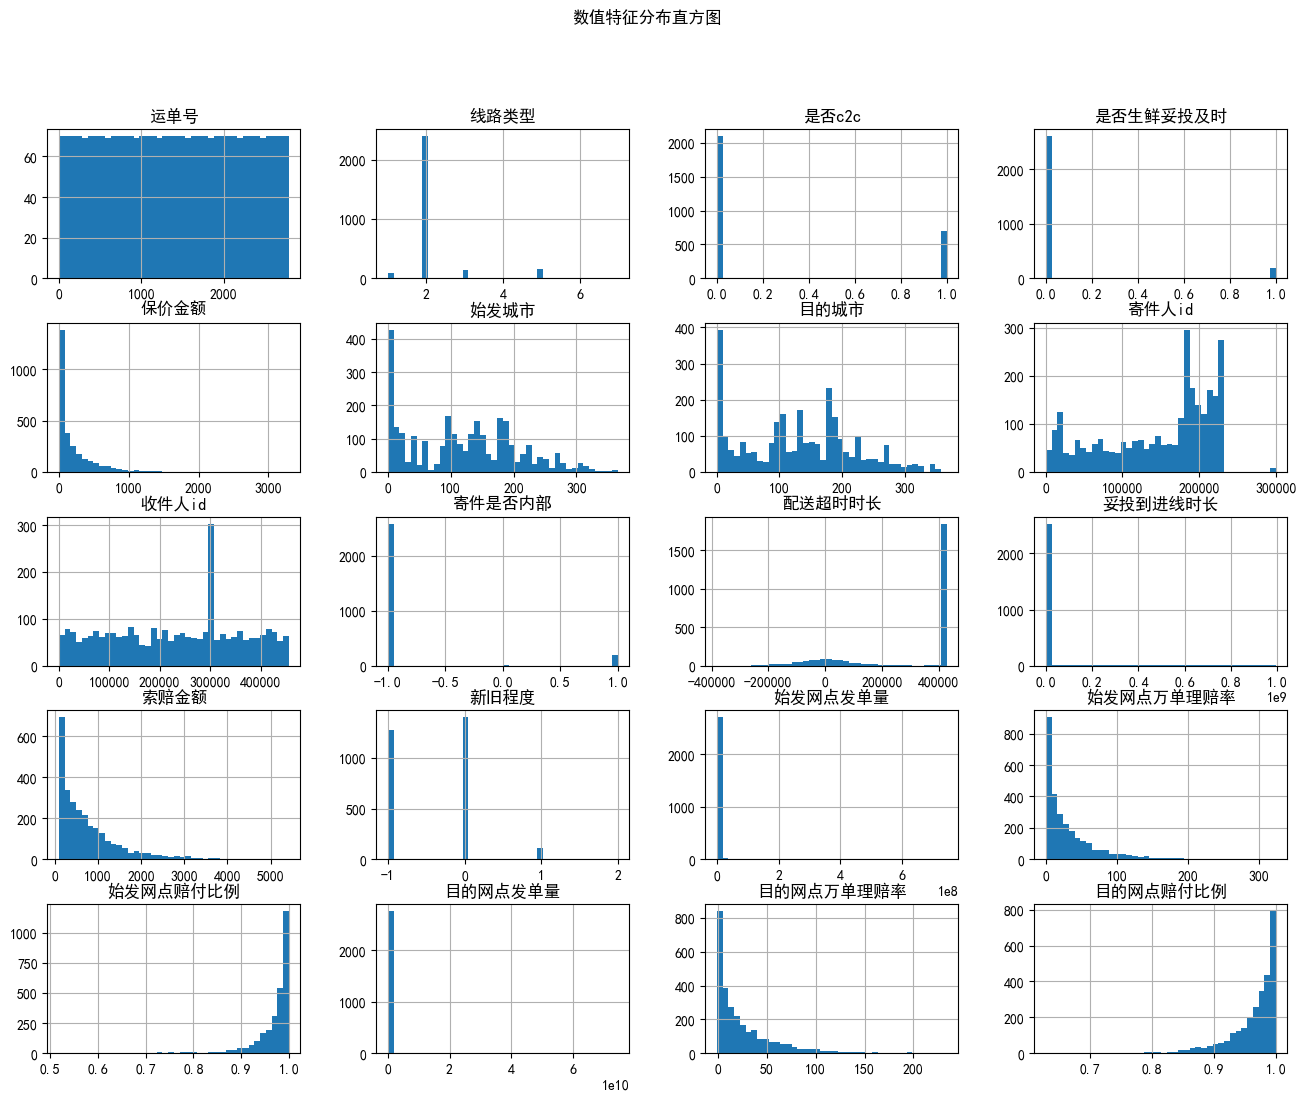


各类别型特征唯一值数量:
异常原因: 5 个唯一值
进线渠道: 6 个唯一值
商品类型: 16 个唯一值
寄件B/C: 4 个唯一值
进线人身份: 4 个唯一值


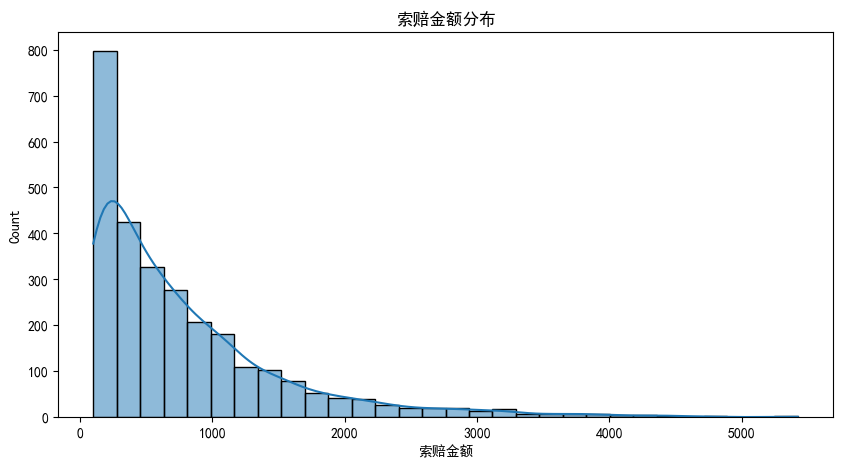

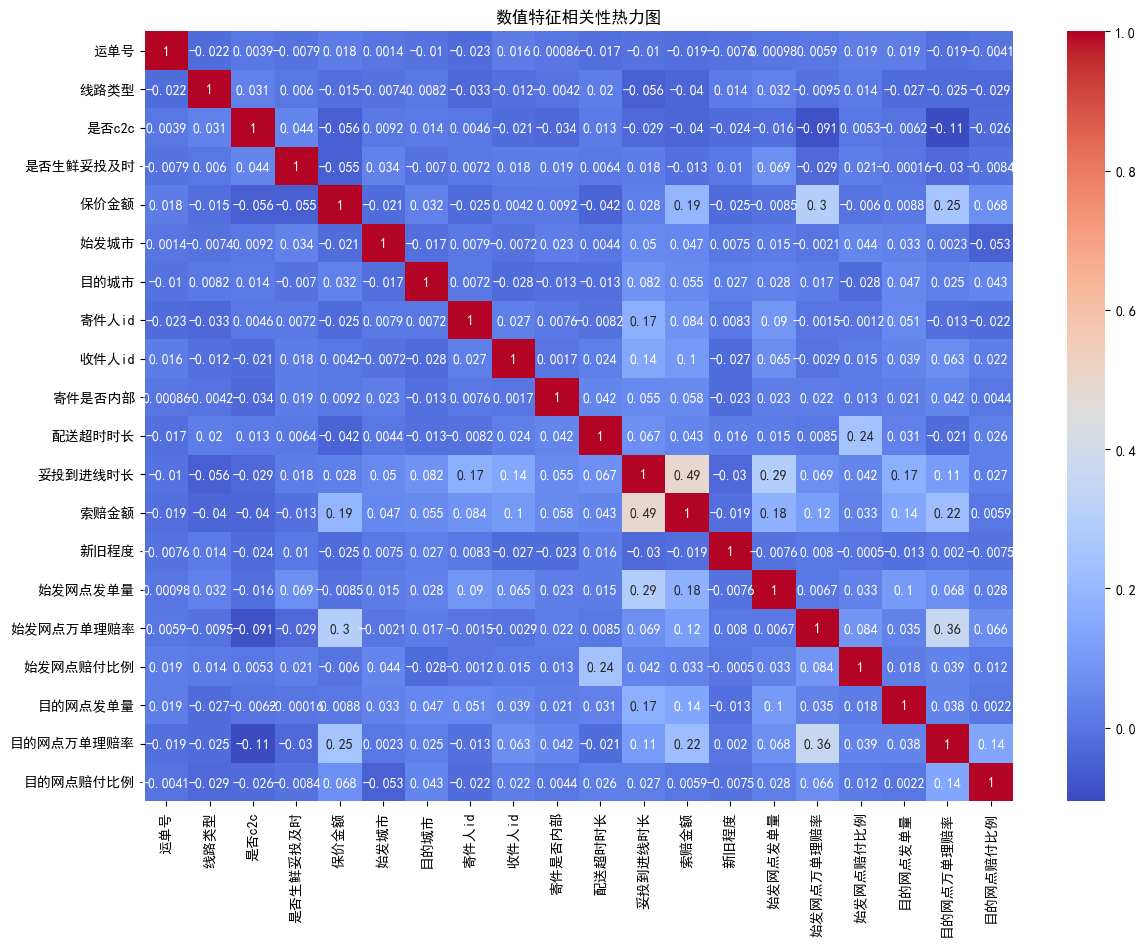

In [70]:
# ========== 【探索性数据分析（EDA）】 ==========
import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 80)
print("探索性数据分析（EDA）")

# 1. 数值特征分布
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[numeric_cols].hist(figsize=(16, 12), bins=40)
print("寄件人总数:", df['寄件人id'].nunique())
print("收件人总数:", df['收件人id'].nunique())
plt.suptitle("数值特征分布直方图")
plt.show()

# 2. 各类别型特征的唯一值统计
categorical_cols = df.select_dtypes(include=['object']).columns
print("\n各类别型特征唯一值数量:")
for col in categorical_cols:
    unique_count = df[col].nunique()
    print(f"{col}: {unique_count} 个唯一值")

# 3. 查看目标变量（如果有，比如'实际赔付金额'和'索赔金额'的分布）
if '实际赔付金额' in df.columns:
    plt.figure(figsize=(10, 5))
    sns.histplot(df['实际赔付金额'], bins=30, kde=True)
    plt.title('实际赔付金额分布')
    plt.show()

if '索赔金额' in df.columns:
    plt.figure(figsize=(10, 5))
    sns.histplot(df['索赔金额'], bins=30, kde=True)
    plt.title('索赔金额分布')
    plt.show()

# 4. 相关性热力图
plt.figure(figsize=(14, 10))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('数值特征相关性热力图')
plt.show()



In [71]:
# ========== 【数据处理】 ==========
print("=" * 80)
print("数据处理")
print("=" * 80)

# 1. 异常原因数值编码（未知=0，其他按字母顺序编码为1,2,3...）
print("\n【1】异常原因数值编码")

# 处理空值（空表示为0）
df['异常原因'] = df['异常原因'].fillna('未知')

# 获取所有唯一值，排序后编码，"未知"编码为0
unique_reasons = sorted(df['异常原因'].unique())
# 将"未知"放在第一位
if '未知' in unique_reasons:
    unique_reasons.remove('未知')
    unique_reasons.insert(0, '未知')

# 创建编码字典："未知"=0, 其他按顺序编码为1,2,3...
reason_mapping = {reason: idx for idx, reason in enumerate(unique_reasons)}
df['异常原因_编码'] = df['异常原因'].map(reason_mapping)

print(f"✓ 异常原因数值编码完成")
print(f"编码映射: {reason_mapping}")

# 2. 进线渠道数值编码
print("\n【2】进线渠道数值编码")
print("-" * 60)

if '进线渠道' in df.columns:
    from sklearn.preprocessing import LabelEncoder
    le_channel = LabelEncoder()
    df['进线渠道_编码'] = le_channel.fit_transform(df['进线渠道'].fillna('Unknown'))
    print(f"✓ 进线渠道编码完成")
    print(f"编码映射: {dict(zip(le_channel.classes_, range(len(le_channel.classes_))))}")
else:
    print("✗ 缺少进线渠道列")

# 3. 商品类型数值编码
print("\n【3】商品类型数值编码")
print("-" * 60)

if '商品类型' in df.columns:
    from sklearn.preprocessing import LabelEncoder
    le_product = LabelEncoder()
    df['商品类型_编码'] = le_product.fit_transform(df['商品类型'].fillna('Unknown'))
    print(f"✓ 商品类型编码完成")
    print(f"编码映射: {dict(zip(le_product.classes_, range(len(le_product.classes_))))}")
else:
    print("✗ 缺少商品类型列")

# 4. 进线人身份数值编码
print("\n【4】进线人身份数值编码")
print("-" * 60)

if '进线人身份' in df.columns:
    from sklearn.preprocessing import LabelEncoder
    le_identity = LabelEncoder()
    df['进线人身份_编码'] = le_identity.fit_transform(df['进线人身份'].fillna('Unknown'))
    print(f"✓ 进线人身份编码完成")
    print(f"编码映射: {dict(zip(le_identity.classes_, range(len(le_identity.classes_))))}")
else:
    print("✗ 缺少进线人身份列")

# 5. 妥投到进线时长分桶（合理安排等级）
print("\n【5】妥投到进线时长分桶")
print("-" * 60)

if '妥投到进线时长' in df.columns:
    # 将秒转换为小时进行分桶
    def bucket_complaint_time_secs(value):
        if pd.isna(value):
            return 0
        if value < 0:
            return 0  # 负值单独一桶
        value_hours = value / 3600
        if value_hours == 0:
            return 1  # 刚好0小时
        elif value_hours < 24:
            return 2  # 1-24小时
        elif value_hours < 48:
            return 3  # 24-48小时
        elif value_hours < 72:
            return 4  # 48-72小时
        elif value_hours < 168:
            return 5  # 72-168小时（一周内）
        else:
            return 6  # 超过一周

    df['妥投到进线时长_分桶'] = df['妥投到进线时长'].apply(bucket_complaint_time_secs)
    print("✓ 妥投到进线时长分桶完成")
    print(df['妥投到进线时长_分桶'].value_counts().sort_index())
else:
    print("✗ 缺少妥投到进线时长列")

# 6. 理赔率处理
# 将“始发网点万单理赔率”与“目的网点万单理赔率”小于0的用0替代
for col in ['始发网点万单理赔率', '目的网点万单理赔率']:
    if col in df.columns:
        df.loc[df[col] < 0, col] = 0
        print(f"✓ {col} 负值已替换为0")
    else:
        print(f"✗ 缺少列: {col}")

# 确保数值列没有NaN（用0填充）
numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    nan_count = df[col].isna().sum()
    if nan_count > 0:
        df[col] = df[col].fillna(0)
        print(f"✓ {col} 填充了 {nan_count} 个NaN值")

print(f"\n✓ 数据处理完成")
print(f"数据形状: {df.shape}")
df.to_csv("train_processed.csv", index=False)



数据处理

【1】异常原因数值编码
✓ 异常原因数值编码完成
编码映射: {'未知': 0, 'Damage': 1, 'Handover Error': 2, 'Pickup Error': 3, 'Shipping Error': 4, 'Suspected Lost': 5}

【2】进线渠道数值编码
------------------------------------------------------------
✓ 进线渠道编码完成
编码映射: {'Call': 0, 'Complaint': 1, 'Internal Software': 2, 'Merchant Compensation Claim': 3, 'Mini Program': 4, 'Unknown': 5, 'Vendor Consultation': 6}

【3】商品类型数值编码
------------------------------------------------------------
✓ 商品类型编码完成
编码映射: {'Alcohol': 0, 'Apparel, Footwear & Accessories': 1, 'Appliances': 2, 'Beauty & Daily Essentials': 3, 'Documents & Bills': 4, 'Dried Groceries': 5, 'Electronic Product': 6, 'Fresh': 7, 'Furniture': 8, 'Hardware': 9, 'Home Improvement and Building Material': 10, 'Household Goods': 11, 'Jewelry': 12, 'Maternity & Baby Products': 13, 'Miscellaneous Goods': 14, 'Pharmaceuticals': 15}

【4】进线人身份数值编码
------------------------------------------------------------
✓ 进线人身份编码完成
编码映射: {'Consigner': 0, 'Receiver': 1, 'Staff': 2, 'Unknown': 

In [72]:
# 【步骤2】核心特征工程 - 仅保留必要的特征变换
print("=" * 80)
print("核心特征工程")
print("=" * 80)

from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler

# ========== 1. 生鲜妥投组合类别 ==========
print("\n【1】生鲜妥投组合类别")
print("-" * 60)

# 检查是否已经存在生鲜妥投组合类别_编码（避免重复创建）
if '生鲜妥投组合类别_编码' not in df.columns and '商品类型' in df.columns and '是否生鲜妥投及时' in df.columns:
    # 判断是否为生鲜商品
    # 判断是否生鲜商品：如果“商品类型”列中包含“生鲜”字样（如“生鲜”, "Fresh produce"等），则视为生鲜商品，否则为非生鲜
    # 先获取商品类型中的唯一值
    unique_types = df['商品类型'].astype(str).unique()
    print("商品类型唯一值如下：")
    print(unique_types)
    # Determine if the product is "fresh produce" (生鲜) in English
    # If the "商品类型" (product type) column contains the substring "fresh", consider it as fresh produce; otherwise, not fresh
    df['是否生鲜商品'] = df['商品类型'].astype(str).str.lower().str.contains("fresh").astype(int)
    print("✓ 是否生鲜商品 column added (English check for 'fresh')")
    print(df['是否生鲜商品'].value_counts())


    # 创建三分类组合：非生鲜, 生鲜妥投及时, 生鲜妥投超时
    df['生鲜妥投组合类别'] = df.apply(
        lambda row: '非生鲜' if row['是否生鲜商品'] == 0
        else ('生鲜妥投及时' if row['是否生鲜妥投及时'] == 1
        else '生鲜妥投超时'), axis=1
    )
    print("✓ 生鲜妥投组合类别创建完成")
    print(df['生鲜妥投组合类别'].value_counts())
    
    # 使用LabelEncoder进行三分类编码
    le_fresh = LabelEncoder()
    df['生鲜妥投组合类别_编码'] = le_fresh.fit_transform(df['生鲜妥投组合类别'])
    print(f"✓ 生鲜妥投组合类别编码完成: {dict(zip(le_fresh.classes_, range(len(le_fresh.classes_))))}")
elif '生鲜妥投组合类别_编码' in df.columns:
    print("✓ 生鲜妥投组合类别已存在，跳过")
else:
    print("✗ 缺少商品类型或是否生鲜妥投及时列")

print(df.columns)
if '生鲜妥投组合类别' in df.columns:
    df.drop(columns=['生鲜妥投组合类别'], inplace=True)
    print("✓ '生鲜妥投组合类别' 列已移除")


# 保存清理后的数据
df.to_csv('test_processed.csv', index=False)

核心特征工程

【1】生鲜妥投组合类别
------------------------------------------------------------
商品类型唯一值如下：
['Miscellaneous Goods' 'Hardware' 'Electronic Product'
 'Beauty & Daily Essentials' 'Pharmaceuticals' 'Household Goods'
 'Dried Groceries' 'Appliances' 'Apparel, Footwear & Accessories'
 'Home Improvement and Building Material' 'Alcohol'
 'Maternity & Baby Products' 'Fresh' 'Jewelry' 'Furniture'
 'Documents & Bills']
✓ 是否生鲜商品 column added (English check for 'fresh')
是否生鲜商品
0    2693
1      99
Name: count, dtype: int64
✓ 生鲜妥投组合类别创建完成
生鲜妥投组合类别
非生鲜       2693
生鲜妥投超时      94
生鲜妥投及时       5
Name: count, dtype: int64
✓ 生鲜妥投组合类别编码完成: {'生鲜妥投及时': 0, '生鲜妥投超时': 1, '非生鲜': 2}
Index(['运单号', '线路类型', '是否c2c', '是否生鲜妥投及时', '保价金额', '始发城市', '目的城市', '寄件人id',
       '收件人id', '寄件是否内部', '配送超时时长', '异常原因', '进线渠道', '妥投到进线时长', '索赔金额', '商品类型',
       '新旧程度', '寄件B/C', '进线人身份', '始发网点发单量', '始发网点万单理赔率', '始发网点赔付比例', '目的网点发单量',
       '目的网点万单理赔率', '目的网点赔付比例', '异常原因_编码', '进线渠道_编码', '商品类型_编码', '进线人身份_编码',
       '妥投到进线时长_分桶', '是否生鲜